## Regularization

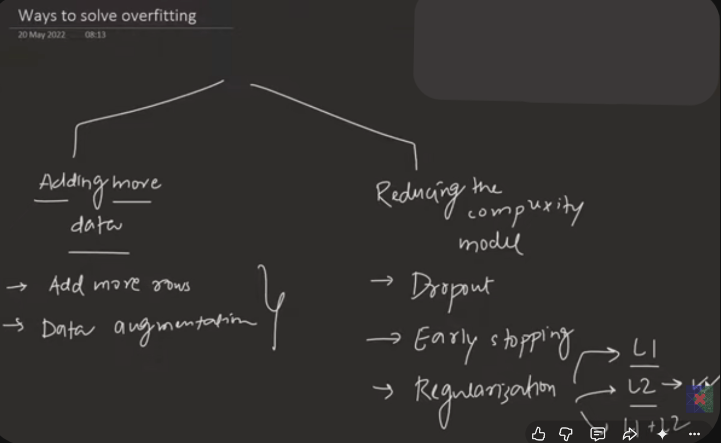


- In regularization we just add a panelty term into the data

L = MSE

$$
C = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})+panalty
$$
$$
L1=C = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})+\frac{\lambda}{n}\sum_{i=1}^{n}||W_i||
$$
$$
L2=C = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})+\frac{\lambda}{n}\sum_{i=1}^{n}||W_i||^2
$$
$$
\text{lambda is hyperparameter?}
$$

#### In ANN it is sometime written as
$$
L2=C = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})+\frac{\lambda}{n}\sum_{l=1}^{n}\sum_{i=1}^{n}\sum_{j=1}^{n}||W_i||^2
$$
$$

# L2 Regularization (Weight Decay)

**Plain GD:** `w_new = w_0 − η·∂L/∂w_0`

**Add L2 penalty to loss:** `L' = L + (λ/2)·Σ‖w_i‖²`
→ penalizes large weights; `λ` controls strength; `/2` cancels cleanly on differentiation.

**Differentiate:** `∂L'/∂w_0 = ∂L/∂w_0 + λ·w_0`

**Plug into GD update:**
```
w_new = w_0 − η(∂L/∂w_0 + λ·w_0)
      = w_0 − ηλ·w_0 − η·∂L/∂w_0
      = (1 − ηλ)·w_0 − η·∂L/∂w_0
```

**Result — the weight decay rule:**
```
w_new = (1 − ηλ)·w_0 − η·∂L/∂w_0
```

**Why "decay":** `(1 − ηλ) < 1` since `η, λ > 0` and small → every update shrinks `w_0` slightly toward zero *before* the gradient step is applied. Weight only stays large if the loss gradient keeps fighting to push it back up — i.e., only if it's genuinely useful.

**Why it helps:** large weights → sharp sensitivity to input → overfitting/memorizing noise. Constant shrinkage discourages that; `λ = 0` → no regularization, `λ` too large → underfitting.

**vs L1:** L1 uses `Σ|w_i|` instead of `Σ‖w_i‖²` — pushes weights to exactly zero (sparsity) rather than just shrinking them.

$$
W_n=(1-\eta\lambda)W_b -\eta\frac{\delta{L}}{\delta{W_0}}
$$

####  L1 may lead to  0 as it mod in it to it forms the graph as 

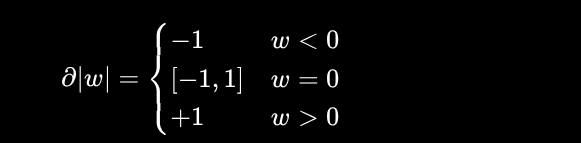

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [7]:
from sklearn.datasets import make_moons

In [8]:
X,y = make_moons(100,noise =0.25,random_state=42)

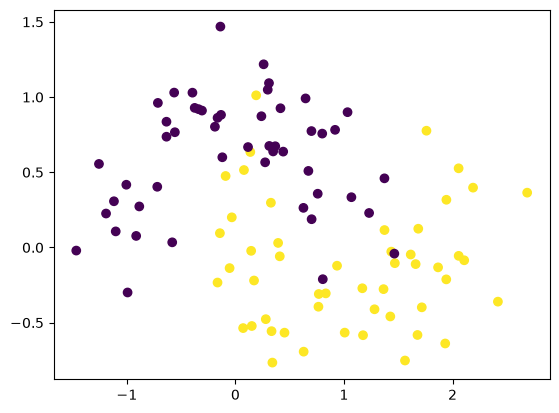

In [10]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y)

In [11]:
model1=Sequential()
model1.add(Dense(256,input_dim=2,activation='relu'))
model1.add(Dense(256,activation='relu'))
#since it is the 
model1.add(Dense(1,activation='sigmoid'))

/run/media/darshchouhan/New Volume/DL-Algorithm/venv/lib64/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1786462836.374721  464210 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,817 (261.00 KB)

 Trainable params: 66,817 (261.00 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])
history = model1.fit(X,y,epochs=2000,validation_split=0.2,validation_freq=10)

Epoch 1/2000


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9750 - loss: 0.0459
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9750 - loss: 0.0381
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9875 - loss: 0.0316
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9875 - loss: 0.0335
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9875 - loss: 0.0350
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9875 - loss: 0.0361
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9875 - loss: 0.0228
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9875 - loss: 0.0263
Epoch 9/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9750 - loss: 0.0289
Epoch 10/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9750 - loss: 0.0296 - val_accuracy: 0.9000 - val_loss: 1.2097
Epoch 11/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9875 - loss: 0.0269
Epoch 12/2000
3/3 ━━━━━━━━━━━━━━━

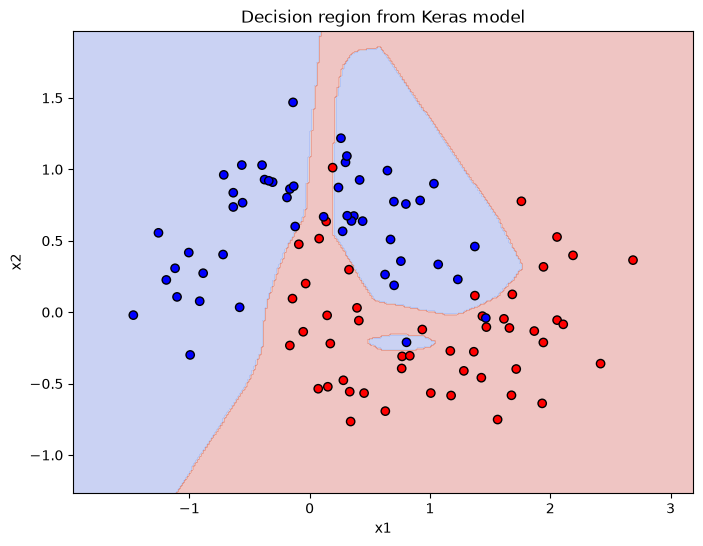

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# after training model1
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300),
)

grid = np.c_[xx.ravel(), yy.ravel()]
probs = model1.predict(grid, verbose=0)
Z = (probs > 0.5).astype(int).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision region from Keras model')
plt.show()

<Axes: >

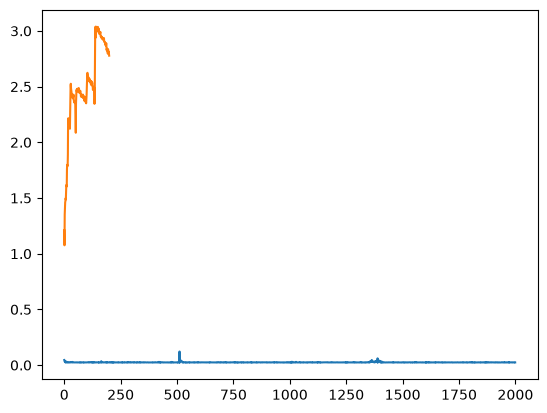

In [30]:
import seaborn as sns
sns.lineplot(history.history['loss'])
sns.lineplot(history.history['val_loss'])

In [32]:
import tensorflow

In [35]:
model1=Sequential()
model1.add(Dense(256,input_dim=2,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model1.add(Dense(256,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.l1(0.01)))
#since it is the 
model1.add(Dense(1,activation='sigmoid'))

In [36]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])
history = model1.fit(X,y,epochs=2000,validation_split=0.2,validation_freq=10)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7625 - loss: 31.4993
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8125 - loss: 17.0621
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8250 - loss: 8.7144 
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8250 - loss: 6.2448
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8375 - loss: 6.9687
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8500 - loss: 5.8491
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8500 - loss: 4.1922
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8625 - loss: 3.3804
Epoch 9/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8500 - loss: 3.2562
Epoch 10/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8500 - loss: 2.7455 - val_accuracy: 0.8000 - val_loss: 2.4837
Epoch 11/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8500 - loss: 2.3305
Epoch 12/2000
3/3

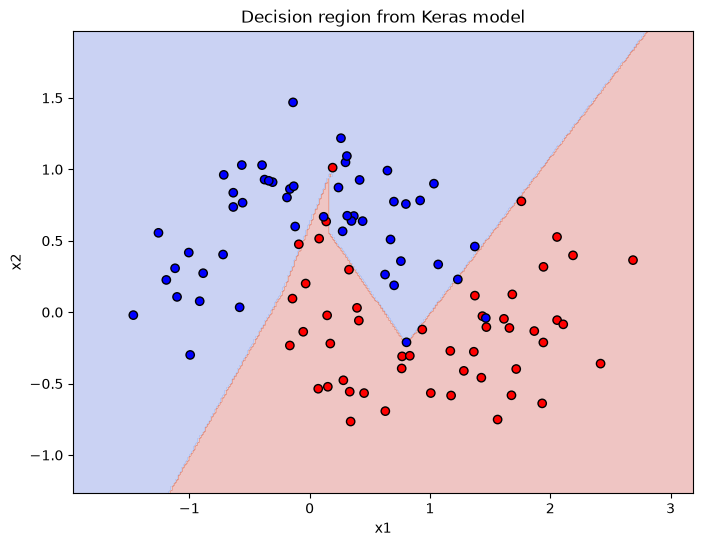

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# after training model1
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300),
)

grid = np.c_[xx.ravel(), yy.ravel()]
probs = model1.predict(grid, verbose=0)
Z = (probs > 0.5).astype(int).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision region from Keras model')
plt.show()